# 06 — K-Means Seasonal Pollution Clustering
**Gurugram Air Quality Study (2020–2024)**

Groups days into pollution clusters using K-Means. Identifies distinct pollution regimes (Winter stagnation, Monsoon washout, Summer dispersion, Post-Monsoon recovery).

**Features:** PM₂.₅, PM₁₀, NO₂, CO, LST, Wind Speed, Relative Humidity  
**Output:** Elbow + Silhouette plots, PCA cluster scatter, cluster centroid table.

**Requires:** Run `01_data_preprocessing.ipynb` first.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "font.size": 11})

BASE = os.getcwd()
OUT  = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(os.path.join(OUT, "merged_clean.csv"), parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"Loaded: {df.shape}")

Loaded: (1768, 32)


## 1. Select Clustering Features

In [2]:
CLUSTER_FEATURES = [
    "PM2.5 (µg/m³)", "PM10 (µg/m³)", "NO2 (µg/m³)",
    "CO (mg/m³)", "LST_C", "WS (m/s)", "RH (%)", "AT (°C)",
]
CLUSTER_FEATURES = [f for f in CLUSTER_FEATURES if f in df.columns]
print(f"Clustering features: {CLUSTER_FEATURES}")

cluster_df = df[["date", "season", "month"] + CLUSTER_FEATURES].copy()
cluster_df = cluster_df.dropna(subset=CLUSTER_FEATURES[:3])  # need at least PM cols

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(cluster_df[CLUSTER_FEATURES])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Clustering rows: {len(X_scaled)}")

Clustering features: ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'CO (mg/m³)', 'LST_C', 'WS (m/s)', 'RH (%)', 'AT (°C)']
Clustering rows: 15


## 2. Elbow Method — Choose Optimal k

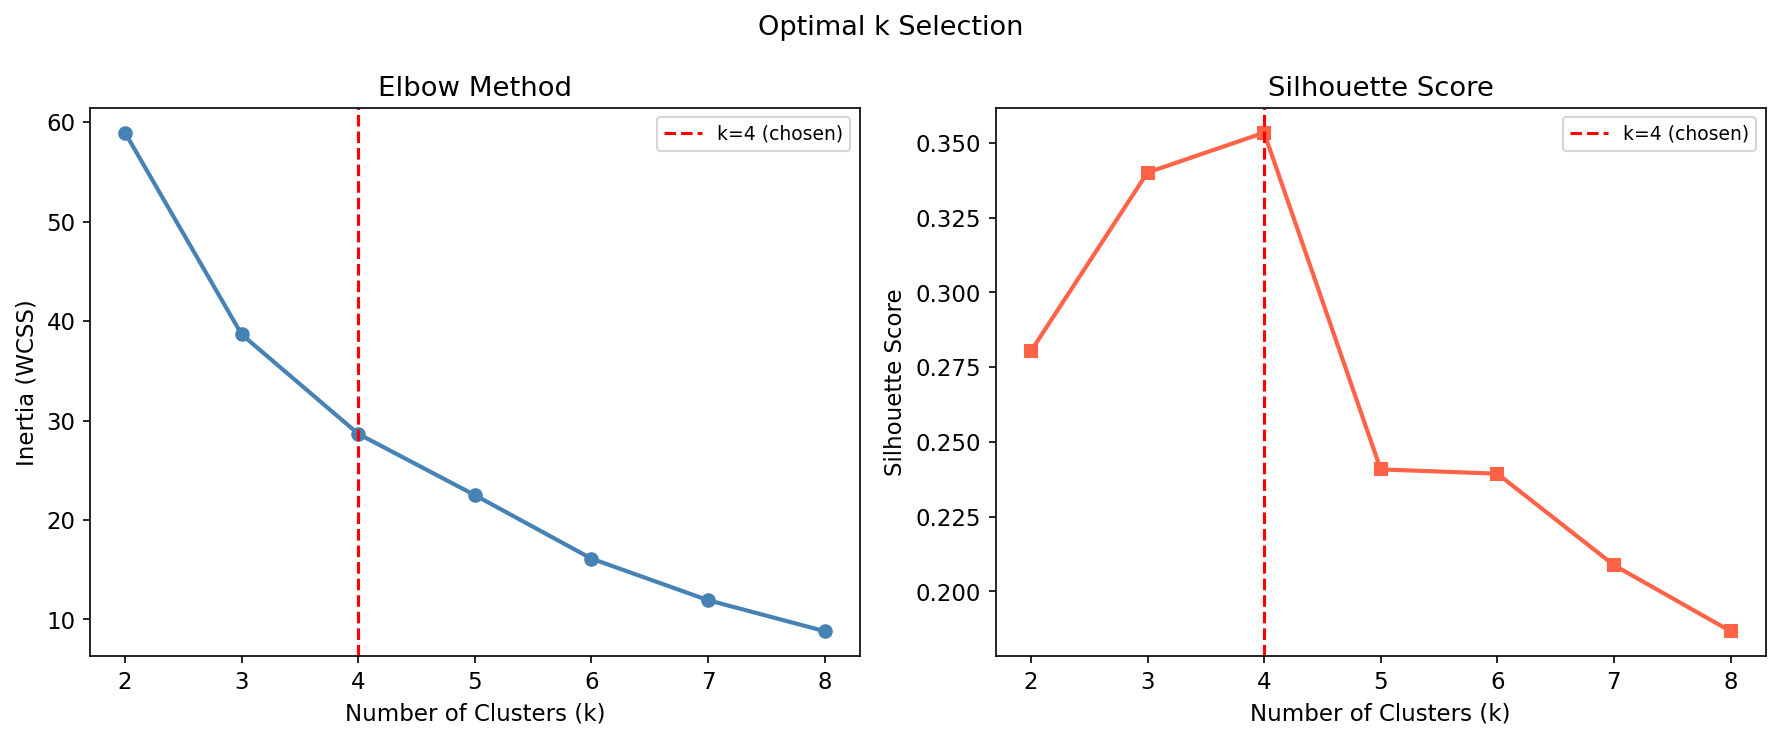

Silhouette scores: {2: 0.28, 3: 0.34, 4: 0.353, 5: 0.241, 6: 0.239, 7: 0.209, 8: 0.187}


In [3]:
inertias    = []
sil_scores  = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(K_range), inertias, "o-", color="steelblue", lw=2)
axes[0].axvline(4, color="red", ls="--", lw=1.5, label="k=4 (chosen)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")
axes[0].legend(fontsize=9)

axes[1].plot(list(K_range), sil_scores, "s-", color="tomato", lw=2)
axes[1].axvline(4, color="red", ls="--", lw=1.5, label="k=4 (chosen)")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].legend(fontsize=9)

plt.suptitle("Optimal k Selection", fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "kmeans_elbow_silhouette.png"))
plt.show()

print(f"Silhouette scores: {dict(zip(K_range, [round(s,3) for s in sil_scores]))}")

## 3. Fit K-Means with k=4

In [4]:
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
cluster_df["cluster"] = km_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(cluster_df["cluster"].value_counts().sort_index())

print("\nSeason distribution per cluster:")
print(pd.crosstab(cluster_df["cluster"], cluster_df["season"]))

Cluster sizes:
cluster
0    2
1    7
2    2
3    4
Name: count, dtype: int64

Season distribution per cluster:
season   Winter
cluster        
0             2
1             7
2             2
3             4


## 4. Cluster Centroid Table

In [5]:
centroids = cluster_df.groupby("cluster")[CLUSTER_FEATURES].mean().round(2)

# Auto-label clusters by PM2.5 level
pm_col = "PM2.5 (µg/m³)"
if pm_col in centroids.columns:
    rank = centroids[pm_col].rank().astype(int)
    label_map = {
        rank.idxmin(): "Low Pollution (Monsoon)",
        rank.nlargest(2).index[-1]: "Moderate Pollution",
        rank.nlargest(3).index[-1]: "High Pollution (Post-Monsoon)",
        rank.idxmax(): "Severe Pollution (Winter)",
    }
    centroids.index = [label_map.get(i, f"Cluster {i}") for i in centroids.index]

print("\n══════════════════════════════════════════════════════════")
print("            CLUSTER CENTROID TABLE")
print("══════════════════════════════════════════════════════════")
print(centroids.T.to_string())
print("══════════════════════════════════════════════════════════")

centroids.to_csv(os.path.join(OUT, "kmeans_centroids.csv"))
print("\nSaved → outputs/kmeans_centroids.csv")
centroids


══════════════════════════════════════════════════════════
            CLUSTER CENTROID TABLE
══════════════════════════════════════════════════════════
               Low Pollution (Monsoon)  Moderate Pollution  Severe Pollution (Winter)  High Pollution (Post-Monsoon)
PM2.5 (µg/m³)                    59.30              189.32                     278.44                         101.01
PM10 (µg/m³)                     96.45              300.72                     543.14                         155.46
NO2 (µg/m³)                      21.14               21.28                      21.14                          20.80
CO (mg/m³)                        1.04                3.49                       3.48                           3.35
LST_C                              NaN                 NaN                        NaN                            NaN
WS (m/s)                          0.92                0.84                       0.92                           0.96
RH (%)                     

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),CO (mg/m³),LST_C,WS (m/s),RH (%),AT (°C)
Low Pollution (Monsoon),59.30,96.45,21.14,1.04,NaN,0.92,NaN,NaN
Moderate Pollution,189.32,300.72,21.28,3.49,NaN,0.84,88.62,NaN
Severe Pollution (Winter),278.44,543.14,21.14,3.48,NaN,0.92,80.02,NaN
High Pollution (Post-Monsoon),101.01,155.46,20.80,3.35,NaN,0.96,NaN,NaN


## 5. PCA Cluster Scatter Plot

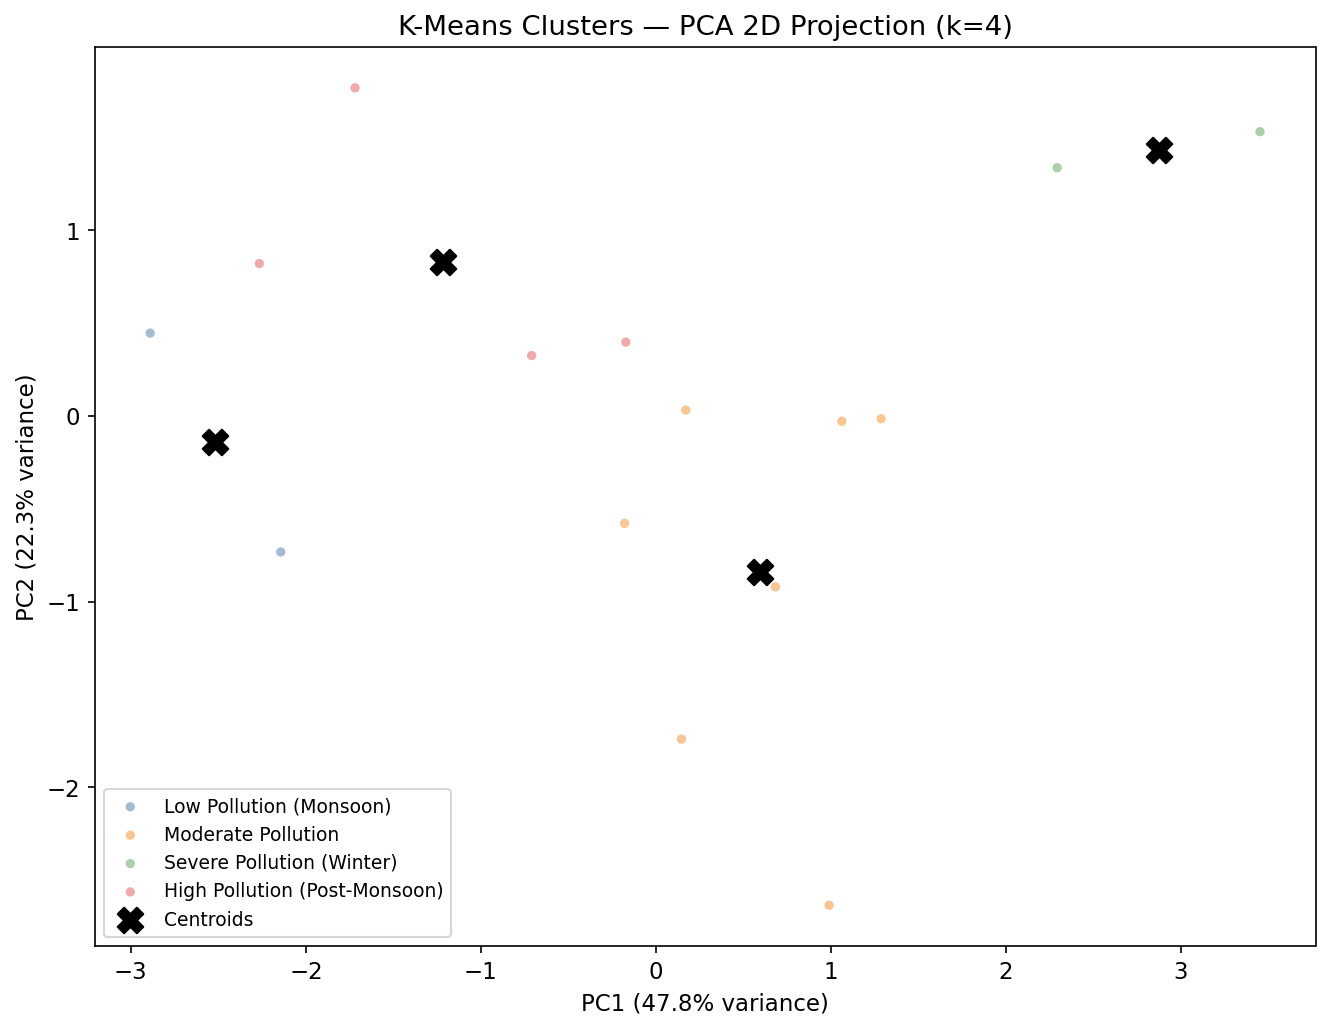

PCA variance explained: PC1=47.8%, PC2=22.3%


In [6]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

cluster_colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]
cluster_labels = list(label_map.values()) if pm_col in centroids.columns else [f"Cluster {i}" for i in range(K)]

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(K):
    mask = cluster_df["cluster"] == c
    label = label_map.get(c, f"Cluster {c}") if pm_col in centroids.columns else f"Cluster {c}"
    ax.scatter(coords[mask, 0], coords[mask, 1],
               alpha=0.5, s=20, color=cluster_colors[c],
               edgecolors="none", label=label)

# Plot centroids in PCA space
centers_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c="black", s=150, marker="X", zorder=5, label="Centroids")

ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
ax.set_title("K-Means Clusters — PCA 2D Projection (k=4)")
ax.legend(fontsize=9, loc="best")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "kmeans_pca_scatter.png"))
plt.show()

print(f"PCA variance explained: PC1={var_explained[0]:.1f}%, PC2={var_explained[1]:.1f}%")

## 6. Cluster Feature Heatmap

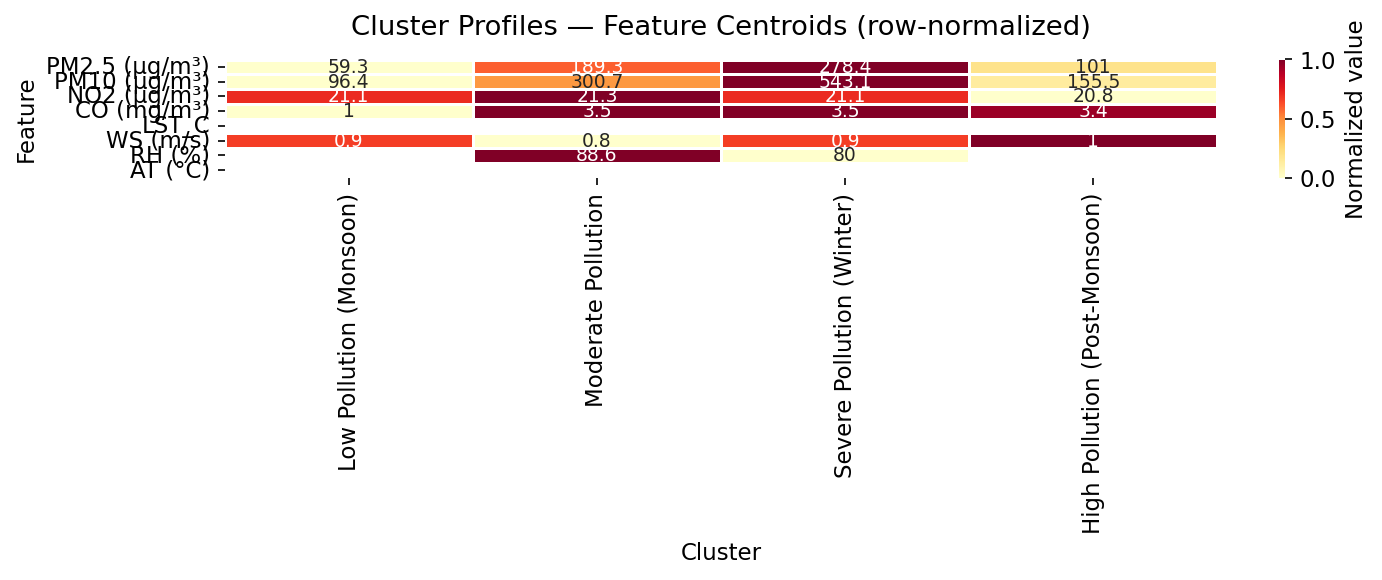

In [7]:
# Normalize centroids for heatmap display
centroids_norm = (centroids - centroids.min()) / (centroids.max() - centroids.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    centroids_norm.T, annot=centroids.T.values.round(1),
    fmt="g", cmap="YlOrRd", linewidths=0.5,
    annot_kws={"size": 9}, ax=ax, cbar_kws={"label": "Normalized value"}
)
ax.set_title("Cluster Profiles — Feature Centroids (row-normalized)", pad=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "kmeans_cluster_heatmap.png"))
plt.show()

## 7. Cluster Distribution Over Time

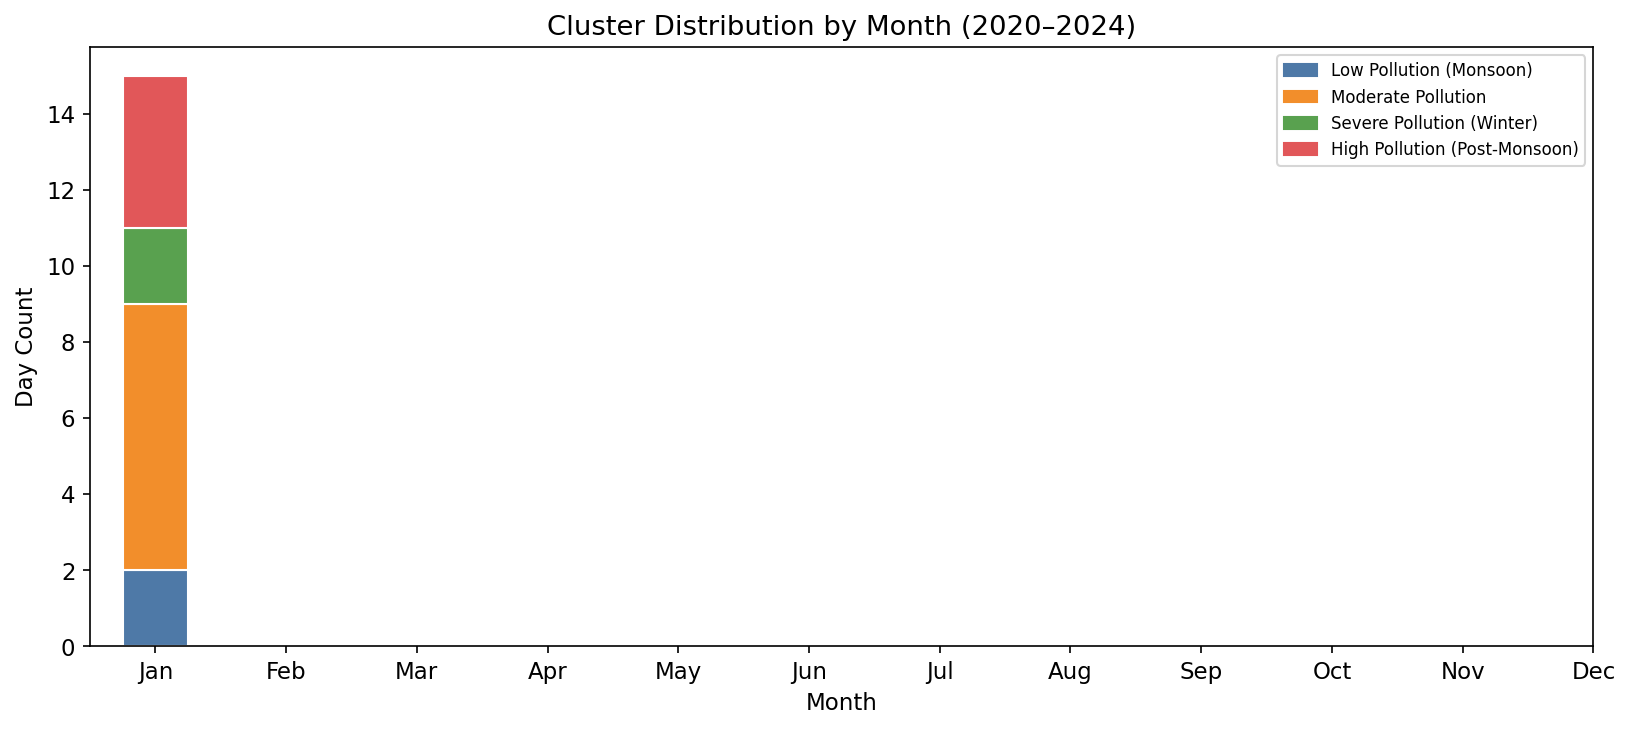

In [8]:
cluster_df["year"] = pd.DatetimeIndex(cluster_df["date"]).year
monthly = cluster_df.groupby(["month", "cluster"]).size().unstack(fill_value=0)
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(11, 5))
monthly.plot.bar(ax=ax, color=cluster_colors[:K], edgecolor="white", stacked=True)
ax.set_xticks(range(12))
ax.set_xticklabels(month_names, rotation=0)
ax.set_xlabel("Month")
ax.set_ylabel("Day Count")
ax.set_title("Cluster Distribution by Month (2020–2024)")

handles = [mpatches.Patch(color=cluster_colors[c],
           label=label_map.get(c, f"Cluster {c}") if pm_col in centroids.columns else f"Cluster {c}")
           for c in range(K)]
ax.legend(handles=handles, fontsize=8, loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "kmeans_monthly_distribution.png"))
plt.show()